<a href="https://colab.research.google.com/github/Yashmax-cmd/aqi-prediction-delhi-ml/blob/main/AQI_prediction_delhi_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data preprocessing**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load dataset
df = pd.read_csv('final_dataset.csv')

# 2. Check missing values
print("Missing values:\n", df.isna().sum())

# 3. Handle missing values (mean imputation)
df.fillna(df.mean(), inplace=True)

# 4. Outlier removal using IQR
numeric_cols = df.select_dtypes(include=['float64','int64']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower, lower,
                       np.where(df[col] > upper, upper, df[col]))

# 5. Feature selection
X = df.drop(columns=['AQI'])
y = df['AQI']

# 6. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Shapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


Missing values:
 Date              0
Month             0
Year              0
Holidays_Count    0
Days              0
PM2.5             0
PM10              0
NO2               0
SO2               0
CO                0
Ozone             0
AQI               0
dtype: int64
Shapes:
X_train: (1168, 11)
X_test: (293, 11)
y_train: (1168,)
y_test: (293,)


Original shape: (1461, 12)
Columns: ['Date', 'Month', 'Year', 'Holidays_Count', 'Days', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'AQI']
After preprocessing shape: (1461, 12)
Train shape: (1168, 11) Test shape: (293, 11)

Linear Regression -> R2: 0.9149, MAE: 22.8203, RMSE: 33.2349

Decision Tree -> R2: 0.8535, MAE: 28.6621, RMSE: 43.6017

Random Forest -> R2: 0.9335, MAE: 19.0860, RMSE: 29.3727


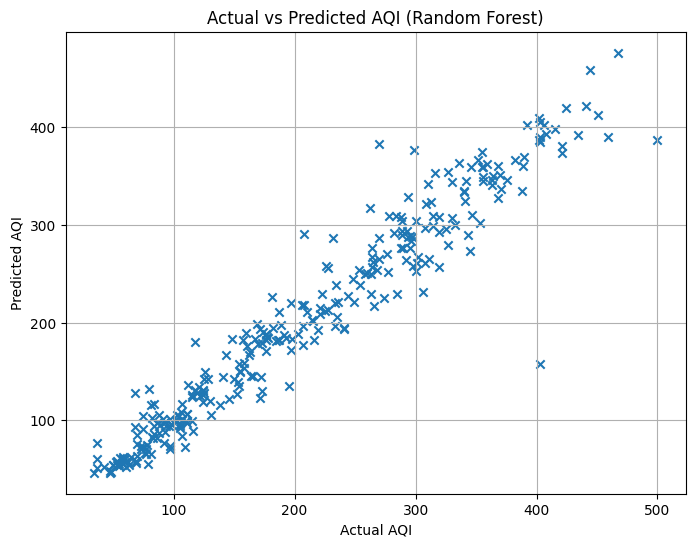

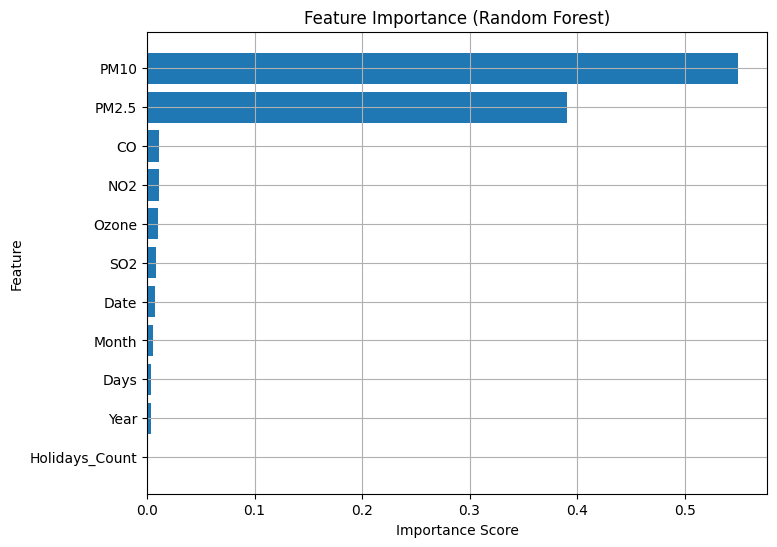

Saved model -> /mnt/data/random_forest_model.pkl
Saved scaler -> /mnt/data/scaler.pkl


In [ ]:
# aqi_pipeline.py
# Full pipeline: load -> preprocess -> split -> train -> evaluate -> visualize -> save model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import os # Import the os module

RANDOM_STATE = 42
DATA_PATH = 'final_dataset.csv'   # change if your CSV is elsewhere
MODEL_PATH = '/mnt/data/random_forest_model.pkl'
SCALER_PATH = '/mnt/data/scaler.pkl'
FIG_ACTUAL_PRED = '/mnt/data/actual_vs_predicted.png'
FIG_FEATURE_IMP = '/mnt/data/feature_importance.png'

def load_data(path):
    df = pd.read_csv(path)
    return df

def handle_missing(df):
    # Use mean imputation for numeric columns
    df = df.copy()
    df.fillna(df.mean(numeric_only=True), inplace=True)
    return df

def cap_outliers_iqr(df):
    df = df.copy()
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        # cap values to lower/upper
        df[col] = np.where(df[col] < lower, lower,
                          np.where(df[col] > upper, upper, df[col]))
    return df

def preprocess(df):
    df = handle_missing(df)
    df = cap_outliers_iqr(df)
    return df

def prepare_features(df, target_col='AQI'):
    X = df.drop(columns=[target_col])
    y = df[target_col]
    return X, y

def scale_features(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, scaler

def train_models(X_train, y_train):
    models = {
        "Linear Regression": LinearRegression(),
        "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
        "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=200)
    }
    trained = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        trained[name] = model
    return trained

def evaluate_model(model, X_test, y_test):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return {"R2": r2, "MAE": mae, "RMSE": rmse, "preds": preds}

def plot_actual_vs_predicted(y_test, preds, save_path=None):
    plt.figure(figsize=(8,6))
    plt.scatter(y_test, preds, marker='x')
    plt.xlabel("Actual AQI")
    plt.ylabel("Predicted AQI")
    plt.title("Actual vs Predicted AQI (Random Forest)")
    plt.grid(True)
    if save_path:
        # Ensure the directory exists before saving
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=200)
    plt.show()

def plot_feature_importance(model, feature_names, save_path=None):
    importances = model.feature_importances_
    # sort
    idx = np.argsort(importances)
    sorted_features = feature_names[idx]
    sorted_importances = importances[idx]

    plt.figure(figsize=(8,6))
    plt.barh(sorted_features, sorted_importances)
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.title("Feature Importance (Random Forest)")
    plt.grid(True)
    if save_path:
        # Ensure the directory exists before saving
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=200)
    plt.show()

def save_model_and_scaler(model, scaler, model_path=MODEL_PATH, scaler_path=SCALER_PATH):
    # Ensure the directory exists before saving
    os.makedirs(os.path.dirname(model_path), exist_ok=True)
    joblib.dump(model, model_path)
    joblib.dump(scaler, scaler_path)
    print(f"Saved model -> {model_path}")
    print(f"Saved scaler -> {scaler_path}")

def main():
    # 1. Load
    df = load_data(DATA_PATH)
    print("Original shape:", df.shape)
    print("Columns:", df.columns.tolist())

    # 2. Preprocess
    df_clean = preprocess(df)
    print("After preprocessing shape:", df_clean.shape)

    # 3. Prepare features/target
    X, y = prepare_features(df_clean, target_col='AQI')

    # 4. Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )
    print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

    # 5. Scale
    X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)

    # 6. Train models
    trained = train_models(X_train_scaled, y_train)

    # 7. Evaluate & print metrics
    results = {}
    for name, model in trained.items():
        res = evaluate_model(model, X_test_scaled, y_test)
        results[name] = {"R2": res["R2"], "MAE": res["MAE"], "RMSE": res["RMSE"]}
        print(f"\n{name} -> R2: {res['R2']:.4f}, MAE: {res['MAE']:.4f}, RMSE: {res['RMSE']:.4f}")

    # 8. Select best model (Random Forest expected)
    rf_model = trained["Random Forest"]
    rf_eval = evaluate_model(rf_model, X_test_scaled, y_test)
    preds = rf_eval["preds"]

    # 9. Plots
    plot_actual_vs_predicted(y_test.values, preds, save_path=FIG_ACTUAL_PRED)
    plot_feature_importance(rf_model, np.array(X.columns), save_path=FIG_FEATURE_IMP)

    # 10. Save model + scaler
    save_model_and_scaler(rf_model, scaler)

    # 11. Optionally: return objects for further use
    return {
        "df_clean": df_clean,
        "X_train": X_train_scaled,
        "X_test": X_test_scaled,
        "y_train": y_train,
        "y_test": y_test,
        "models": trained,
        "scaler": scaler
    }

if __name__ == "__main__":
    artefacts = main()

In [ ]:
#!/usr/bin/env python3
"""
AQI prediction pipeline for Delhi dataset.

Place your CSV at: /mnt/data/final_dataset.csv
Run: python3 aqi_pipeline.py
"""

import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ---------------------------
# Configuration
# ---------------------------
DATA_PATH = "final_dataset.csv"
RANDOM_STATE = 42
TEST_SIZE = 0.2
RF_N_ESTIMATORS = 200
OUTPUT_DIR = "/mnt/data/aqi_outputs"   # change as needed

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------------------------
# Utility functions
# ---------------------------
def load_data(path):
    df = pd.read_csv(path)
    return df

def impute_missing(df):
    # mean imputation for numeric columns only (works with pandas versions that require numeric_only)
    numeric_cols = df.select_dtypes(include=["number"]).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
    # for any remaining non-numeric NA (if any), drop or fill - here we drop rows with any remaining NA
    df = df.dropna().reset_index(drop=True)
    return df

def cap_outliers_iqr(df):
    numeric_cols = df.select_dtypes(include=["number"]).columns
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        # cap values instead of dropping
        df[col] = np.where(df[col] < lower, lower, np.where(df[col] > upper, upper, df[col]))
    return df

def prepare_features(df, target_col="AQI", drop_cols=None):
    if drop_cols is None:
        drop_cols = []
    X = df.drop(columns=[target_col] + drop_cols)
    y = df[target_col].copy()
    return X, y

def scale_features(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return scaler, X_train_scaled, X_test_scaled

def evaluate_model(model, X_test, y_test):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    # avoid using the "squared" kwarg to keep compatibility across sklearn versions
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return {"R2": r2, "MAE": mae, "RMSE": rmse}, preds

# ---------------------------
# Main pipeline
# ---------------------------
def main():
    # 1. Load
    print("Loading data from:", DATA_PATH)
    df = load_data(DATA_PATH)
    print("Original shape:", df.shape)
    print("Columns:", list(df.columns))
    print("-" * 60)

    # 2. Impute missing values
    df_clean = impute_missing(df.copy())
    print("After imputation shape:", df_clean.shape)

    # 3. Outlier capping (IQR)
    df_clean = cap_outliers_iqr(df_clean)
    print("After outlier capping shape:", df_clean.shape)

    # 4. Prepare X, y
    # If you want to drop Date/Month/Year replace drop_cols accordingly; here we keep all numeric columns
    X, y = prepare_features(df_clean, target_col="AQI")
    print("Feature shape (X):", X.shape)
    print("Target shape (y):", y.shape)
    print("-" * 60)

    # 5. Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f"Train shape: {X_train.shape}  Test shape: {X_test.shape}")
    print("-" * 60)

    # 6. Scaling
    scaler, X_train_scaled, X_test_scaled = scale_features(X_train, X_test)

    # 7. Train models
    models = {
        "Linear Regression": LinearRegression(),
        "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
        "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=RF_N_ESTIMATORS),
    }

    results = {}
    preds_store = {}

    for name, model in models.items():
        print(f"Training {name} ...")
        model.fit(X_train_scaled, y_train)
        metrics, preds = evaluate_model(model, X_test_scaled, y_test)
        results[name] = metrics
        preds_store[name] = preds
        print(f" -> {name} metrics: R2={metrics['R2']:.4f}, MAE={metrics['MAE']:.4f}, RMSE={metrics['RMSE']:.4f}")

    print("\nSummary of results:")
    for name, m in results.items():
        print(f"{name:20s} | R2: {m['R2']:.4f} | MAE: {m['MAE']:.4f} | RMSE: {m['RMSE']:.4f}")

    # 8. Select best model (by R2)
    best_model_name = max(results.items(), key=lambda x: x[1]["R2"])[0]
    best_model = models[best_model_name]
    best_preds = preds_store[best_model_name]
    print("-" * 60)
    print("Best model:", best_model_name)

    # 9. Plot Actual vs Predicted for best model
    plt.figure(figsize=(8,6))
    plt.scatter(y_test, best_preds, marker='x')
    plt.xlabel("Actual AQI")
    plt.ylabel("Predicted AQI")
    plt.title(f"Actual vs Predicted AQI ({best_model_name})")
    plt.grid(True)
    plt.tight_layout()
    plot_path1 = os.path.join(OUTPUT_DIR, f"actual_vs_pred_{best_model_name.replace(' ','_')}.png")
    plt.savefig(plot_path1, dpi=150)
    print("Saved plot:", plot_path1)
    plt.close()

    # 10. Feature importance (if RF)
    if hasattr(best_model, "feature_importances_"):
        importances = best_model.feature_importances_
        features = list(X.columns)
        # sort for nicer plotting
        sorted_idx = np.argsort(importances)
        sorted_features = [features[i] for i in sorted_idx]
        sorted_importances = importances[sorted_idx]

        plt.figure(figsize=(8,6))
        plt.barh(sorted_features, sorted_importances)
        plt.xlabel("Importance")
        plt.title(f"Feature Importance ({best_model_name})")
        plt.tight_layout()
        plot_path2 = os.path.join(OUTPUT_DIR, f"feature_importance_{best_model_name.replace(' ','_')}.png")
        plt.savefig(plot_path2, dpi=150)
        print("Saved plot:", plot_path2)
        plt.close()
    else:
        print("Best model has no feature_importances_ attribute (skipping importance plot).")

    # 11. Save best model and scaler
    model_path = os.path.join(OUTPUT_DIR, f"{best_model_name.replace(' ','_')}_model.pkl")
    scaler_path = os.path.join(OUTPUT_DIR, "scaler.pkl")
    joblib.dump(best_model, model_path)
    joblib.dump(scaler, scaler_path)
    print("Saved model to:", model_path)
    print("Saved scaler to:", scaler_path)

    # 12. Save evaluation table
    df_results = pd.DataFrame(results).T
    df_results.to_csv(os.path.join(OUTPUT_DIR, "model_results.csv"))
    print("Saved model results CSV.")

    return {
        "original_shape": df.shape,
        "after_preprocessing_shape": df_clean.shape,
        "X_train_shape": X_train.shape,
        "X_test_shape": X_test.shape,
        "results": results,
        "best_model_name": best_model_name,
        "outputs_dir": OUTPUT_DIR
    }


if __name__ == "__main__":
    artifacts = main()
    print("\nArtifacts summary:")
    for k, v in artifacts.items():
        print(f"{k}: {v}")


Loading data from: final_dataset.csv
Original shape: (1461, 12)
Columns: ['Date', 'Month', 'Year', 'Holidays_Count', 'Days', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'AQI']
------------------------------------------------------------
After imputation shape: (1461, 12)
After outlier capping shape: (1461, 12)
Feature shape (X): (1461, 11)
Target shape (y): (1461,)
------------------------------------------------------------
Train shape: (1168, 11)  Test shape: (293, 11)
------------------------------------------------------------
Training Linear Regression ...
 -> Linear Regression metrics: R2=0.9149, MAE=22.8203, RMSE=33.2349
Training Decision Tree ...
 -> Decision Tree metrics: R2=0.8535, MAE=28.6621, RMSE=43.6017
Training Random Forest ...
 -> Random Forest metrics: R2=0.9335, MAE=19.0860, RMSE=29.3727

Summary of results:
Linear Regression    | R2: 0.9149 | MAE: 22.8203 | RMSE: 33.2349
Decision Tree        | R2: 0.8535 | MAE: 28.6621 | RMSE: 43.6017
Random Forest        | R2: 0.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# -----------------------------
# 1. Load Dataset
# -----------------------------
# Ensure 'final_dataset.csv' is uploaded to your Colab environment.
# You can upload it by clicking the folder icon on the left sidebar,
# then the upload icon, and selecting your file.
df = pd.read_csv("final_dataset.csv")
print("Original shape:", df.shape)
print("Columns:", list(df.columns))

# -----------------------------
# 2. Missing Value Handling
# -----------------------------
df.fillna(df.mean(numeric_only=True), inplace=True)

# -----------------------------
# 3. Outlier Treatment (IQR)
# -----------------------------
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower,
                       np.where(df[col] > upper, upper, df[col]))

print("After preprocessing shape:", df.shape)

# -----------------------------
# 4. Split Features & Target
# -----------------------------
X = df.drop(columns=["AQI"])
y = df["AQI"]

# -----------------------------
# 5. Feature Scaling
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# 6. Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# -----------------------------
# 7. Train Random Forest
# -----------------------------
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)
preds = model.predict(X_test)

# -----------------------------
# 8. Evaluation
# -----------------------------
r2 = r2_score(y_test, preds)
mae = mean_absolute_error(y_test, preds)
rmse = mean_squared_error(y_test, preds) ** 0.5   # NO squared=True → FIXES YOUR ERROR

print("\n===== MODEL PERFORMANCE =====")
print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

# -----------------------------
# 9. Feature Importance
# -----------------------------
importances = model.feature_importances_
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\n===== FEATURE IMPORTANCE =====")
print(feature_importance)


Original shape: (1461, 12)
Columns: ['Date', 'Month', 'Year', 'Holidays_Count', 'Days', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'AQI']
After preprocessing shape: (1461, 12)
Train shape: (1168, 11) Test shape: (293, 11)

===== MODEL PERFORMANCE =====
R2 Score: 0.9336392650252912
MAE: 19.062525597269623
RMSE: 29.345148868527502

===== FEATURE IMPORTANCE =====
           Feature  Importance
6             PM10    0.549237
5            PM2.5    0.390382
9               CO    0.011473
7              NO2    0.011202
10           Ozone    0.010022
8              SO2    0.007933
0             Date    0.007023
1            Month    0.005385
4             Days    0.003862
2             Year    0.003482
3   Holidays_Count    0.000000


**📊 DATA VISUALIZATION**

<Figure size 1500x1500 with 0 Axes>

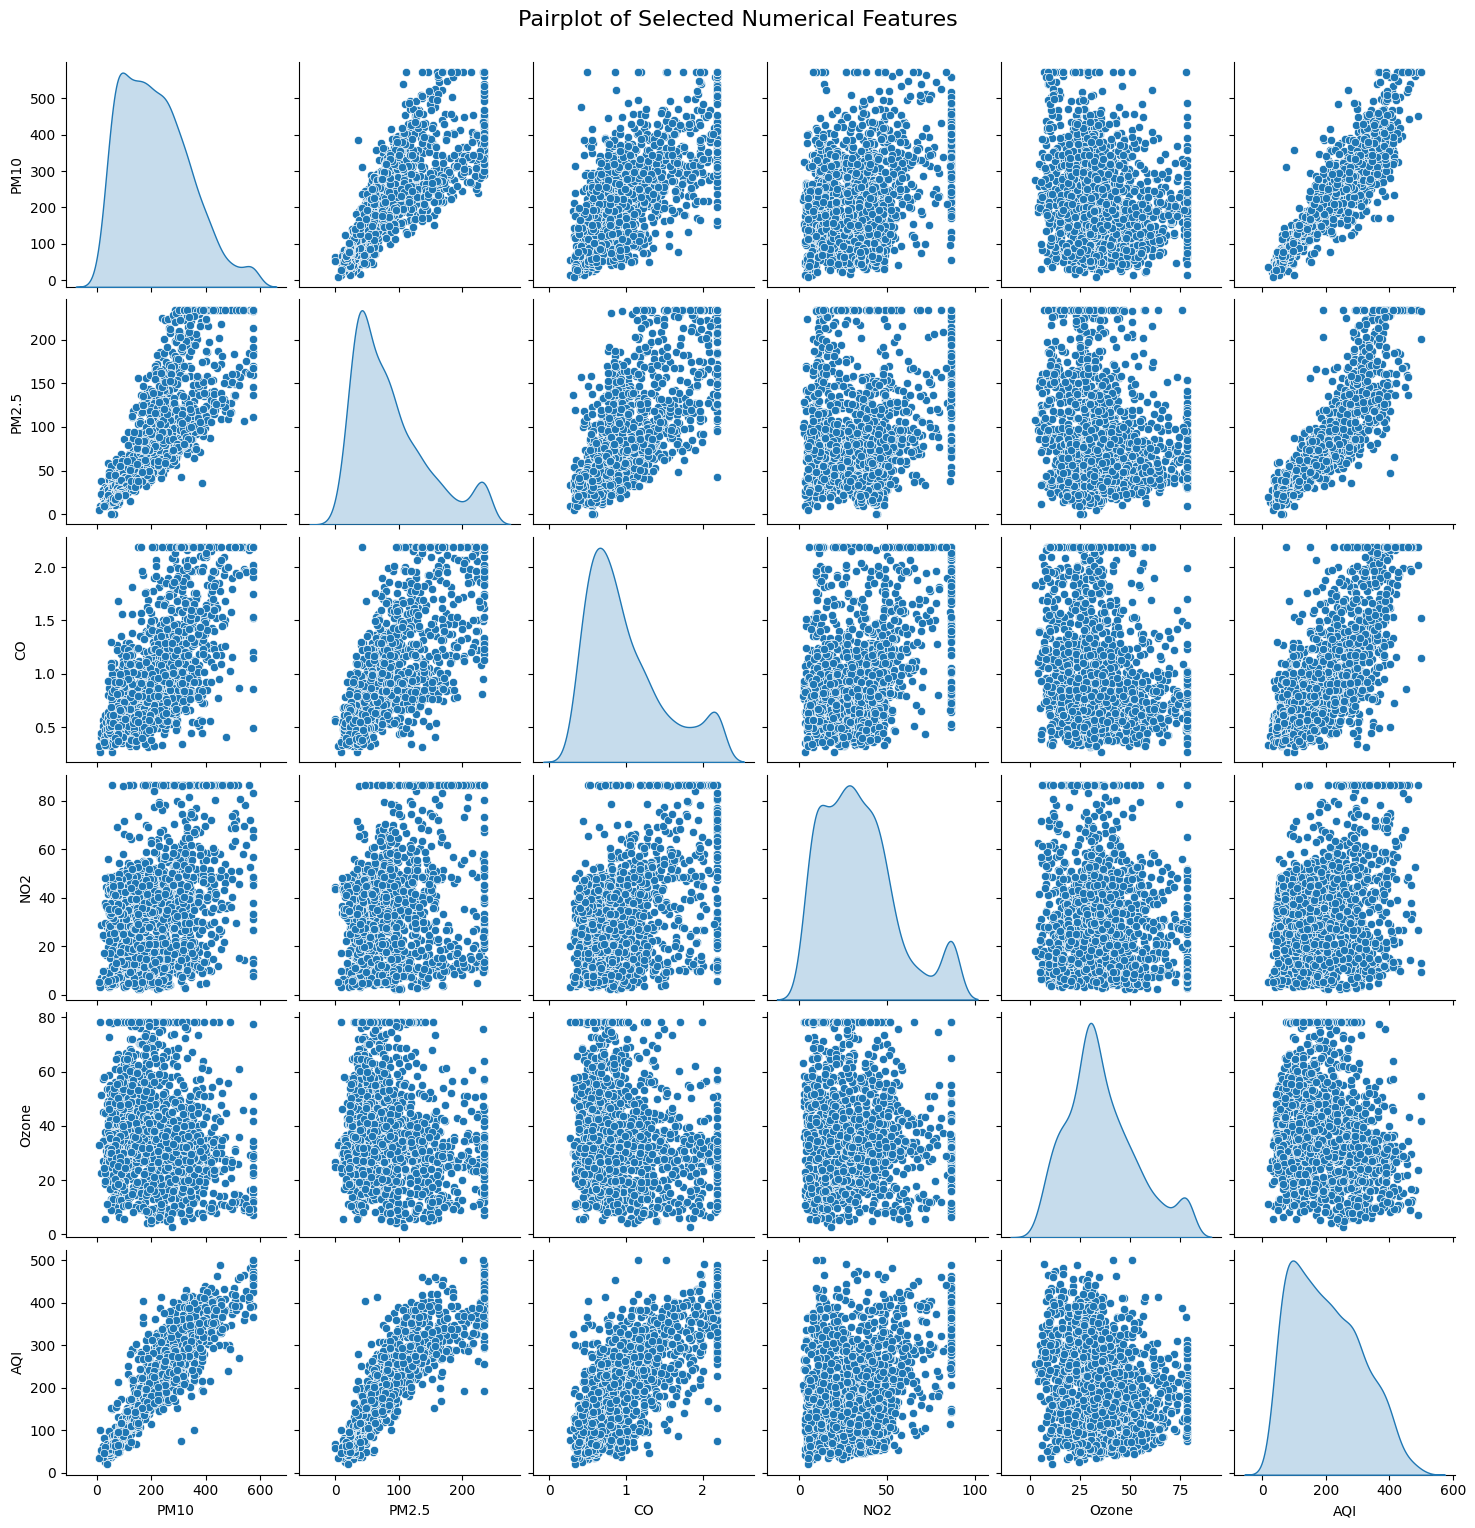

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 'numeric_df' is defined from previous steps (excluding 'Holidays_Count')
# If this cell is run independently, you might need to re-run the data loading and preprocessing.

# Generate the pairplot for the numerical features
# sns.pairplot(numeric_df) is generally too heavy for many features.
# Let's select a subset of highly correlated features and the target 'AQI' for a more focused pairplot.

# First, let's redefine df and numeric_df to ensure it's available.
import pandas as pd
import numpy as np
df = pd.read_csv("final_dataset.csv")
df.fillna(df.mean(numeric_only=True), inplace=True)
numeric_cols_all = df.select_dtypes(include=["int64", "float64"]).columns
for col_name in numeric_cols_all:
    Q1 = df[col_name].quantile(0.25)
    Q3 = df[col_name].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col_name] = np.where(df[col_name] < lower, lower,
                       np.where(df[col_name] > upper, upper, df[col_name]))

numeric_df = df.select_dtypes(include=['float64', 'int64'])
if 'Holidays_Count' in numeric_df.columns:
    numeric_df = numeric_df.drop(columns=['Holidays_Count'])

# Select top features based on correlation with AQI, and include AQI itself for the pairplot
# Assuming 'AQI' is the target and is present in numeric_df
if 'AQI' in numeric_df.columns:
    corr_with_aqi = numeric_df.corr()['AQI'].abs().sort_values(ascending=False)
    # Select top 5 correlated features + AQI for the pairplot to keep it manageable
    top_features = corr_with_aqi.index[1:6].tolist() + ['AQI'] # Exclude AQI from top correlated list, then add it
    pairplot_df = numeric_df[top_features]
else:
    print("'AQI' column not found in numeric_df. Generating pairplot for a subset of other numeric columns.")
    # Fallback if AQI is not present, pick some other features
    pairplot_df = numeric_df[['PM2.5', 'PM10', 'NO2', 'CO']].copy()

plt.figure(figsize=(15, 15))
sns.pairplot(pairplot_df, diag_kind='kde') # Use kde for diagonal distribution plots
plt.suptitle('Pairplot of Selected Numerical Features', y=1.02, fontsize=16)
plt.show()

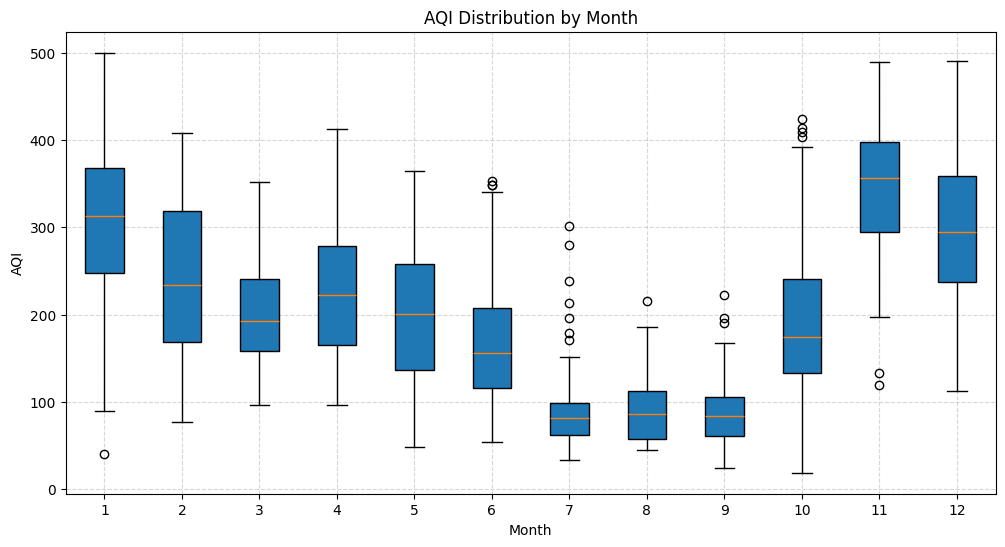

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("final_dataset.csv")

# Ensure numeric
df["AQI"] = pd.to_numeric(df["AQI"], errors="coerce")
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")

# Drop missing values if any
df = df.dropna(subset=["AQI", "Month"])

# Group AQI values month-wise
data_by_month = [df[df["Month"] == m]["AQI"].values for m in range(1, 13)]

plt.figure(figsize=(12, 6))
plt.boxplot(data_by_month, patch_artist=True)

# Colors for each month (like seaborn palette)
colors = [
    "#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f",
    "#e5c494", "#b3b3b3", "#a1dab4", "#41b6c4", "#2c7fb8", "#253494"
]

for patch, color in zip(plt.gca().artists, colors):
    patch.set_facecolor(color)

plt.title("AQI Distribution by Month")
plt.xlabel("Month")
plt.ylabel("AQI")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()


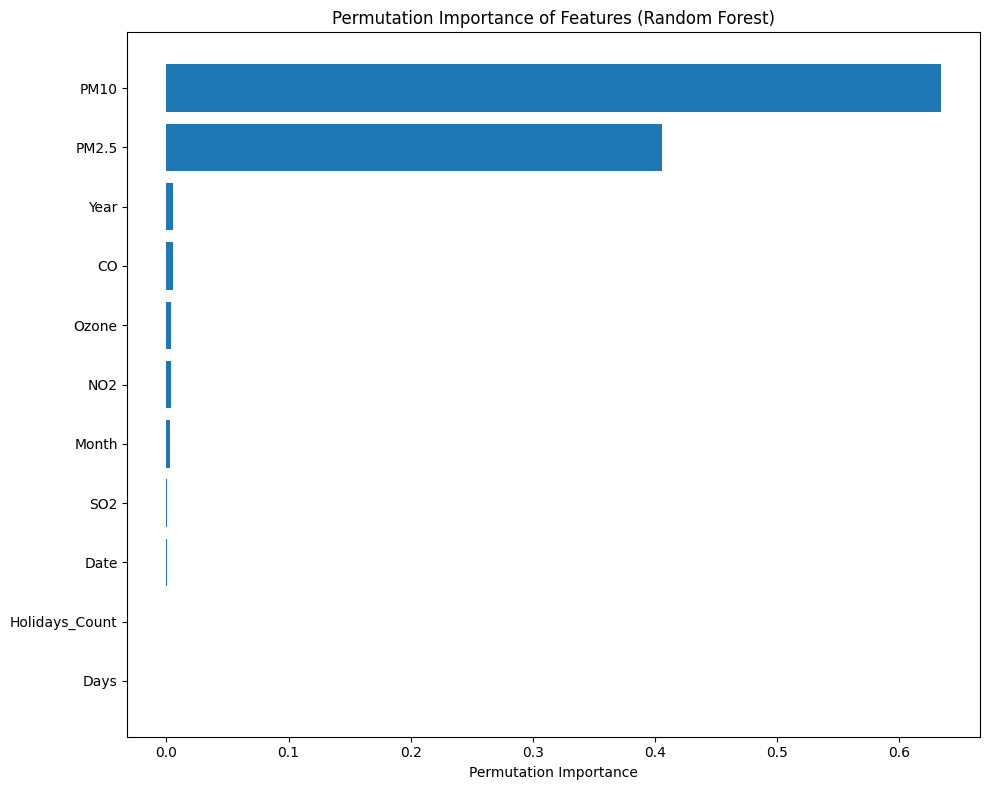

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Re-run data preparation to ensure X, y, X_train, X_test, y_train, y_test, and model are available
# This ensures the cell is self-contained if run out of order.

df = pd.read_csv("final_dataset.csv")
df.fillna(df.mean(numeric_only=True), inplace=True)
numeric_cols_all = df.select_dtypes(include=["int64", "float64"]).columns
for col_name in numeric_cols_all:
    Q1 = df[col_name].quantile(0.25)
    Q3 = df[col_name].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col_name] = np.where(df[col_name] < lower, lower,
                       np.where(df[col_name] > upper, upper, df[col_name]))

X = df.drop(columns=["AQI"])
y = df["AQI"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
model.fit(X_train, y_train)

# Calculate permutation importance
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize results into a DataFrame
feature_names = X.columns
sorted_idx = result.importances_mean.argsort()

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feature_names[sorted_idx], result.importances_mean[sorted_idx])
ax.set_xlabel("Permutation Importance")
ax.set_title("Permutation Importance of Features (Random Forest)")
plt.tight_layout()
plt.show()


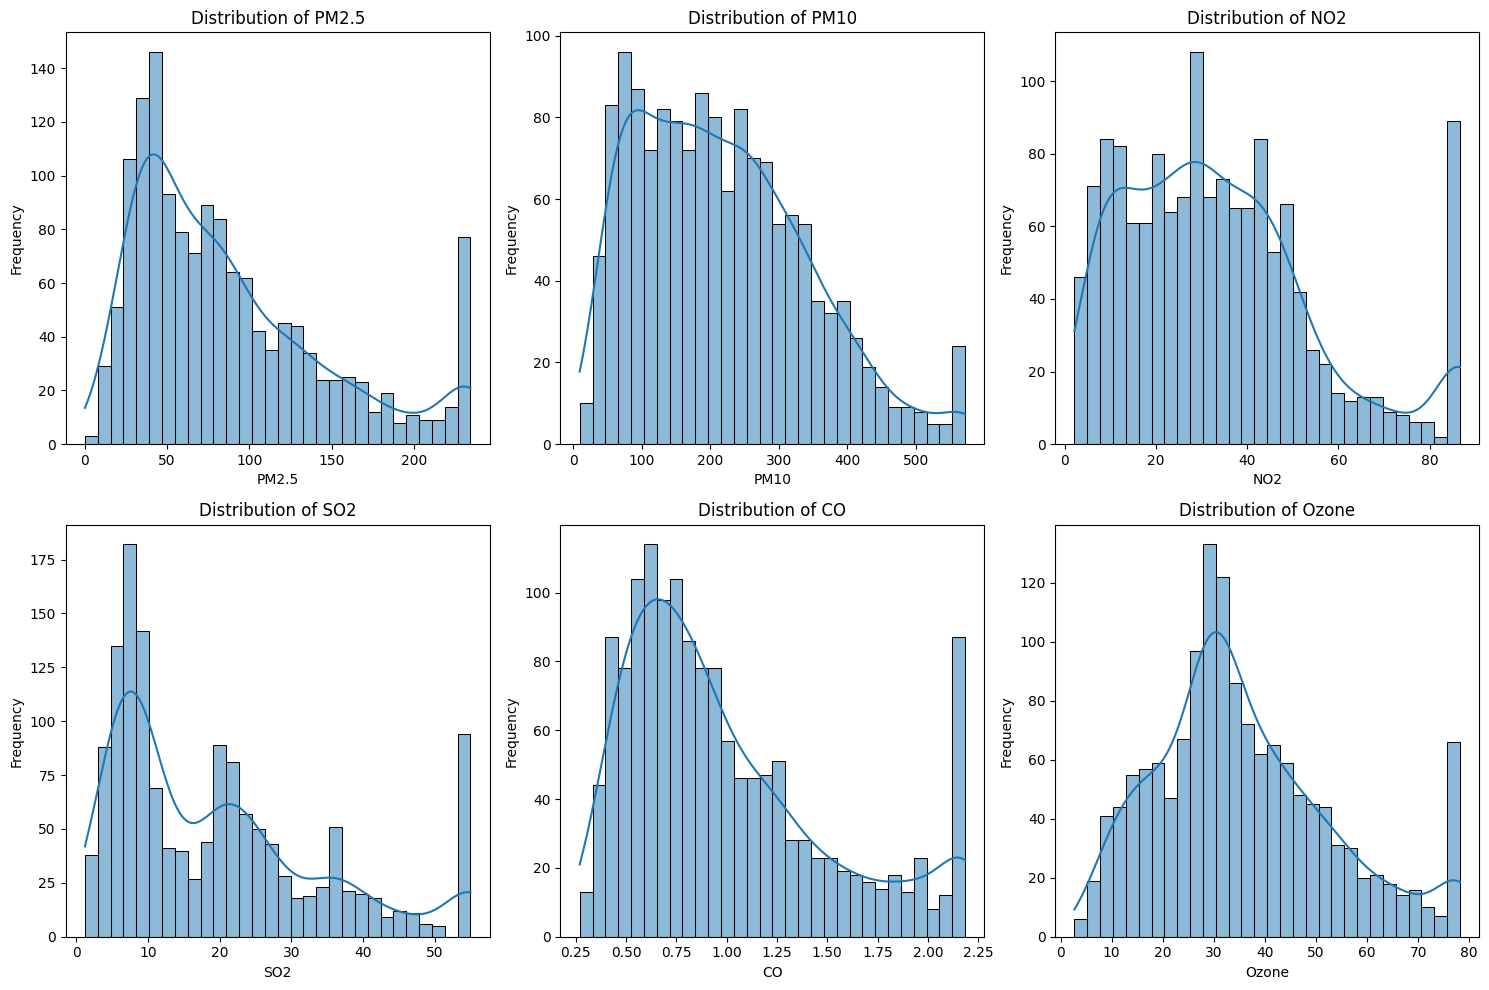

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Re-run data preparation to ensure df is available
df = pd.read_csv("final_dataset.csv")
df.fillna(df.mean(numeric_only=True), inplace=True)
numeric_cols_all = df.select_dtypes(include=["int64", "float64"]).columns
for col_name in numeric_cols_all:
    Q1 = df[col_name].quantile(0.25)
    Q3 = df[col_name].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col_name] = np.where(df[col_name] < lower, lower,
                       np.where(df[col_name] > upper, upper, df[col_name]))

# List of pollutant columns
pollutant_cols = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone']

# Create histograms for each pollutant
plt.figure(figsize=(15, 10))
for i, col in enumerate(pollutant_cols, 1):
    plt.subplot(2, 3, i) # Arrange in 2 rows, 3 columns
    sns.histplot(df[col], kde=True, bins=30) # Using histplot for better visualization with KDE
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

R2: 0.9336392650252912
MAE: 19.062525597269623
RMSE: 29.345148868527502


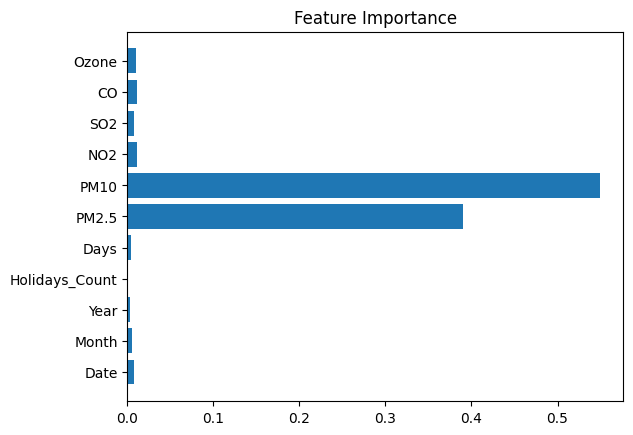

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

df = pd.read_csv("final_dataset.csv")

df.fillna(df.mean(numeric_only=True), inplace=True)

numeric_cols = df.select_dtypes(include=['float64','int64']).columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower, lower,
             np.where(df[col] > upper, upper, df[col]))

features = ['Date','Month','Year','Holidays_Count','Days',
            'PM2.5','PM10','NO2','SO2','CO','Ozone']

X = df[features]
y = df['AQI']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,y,test_size=0.2,random_state=42)

model = RandomForestRegressor(n_estimators=200,random_state=42)
model.fit(X_train,y_train)

preds = model.predict(X_test)

r2 = r2_score(y_test,preds)
mae = mean_absolute_error(y_test,preds)
rmse = np.sqrt(mean_squared_error(y_test,preds))

print("R2:",r2)
print("MAE:",mae)
print("RMSE:",rmse)

importances = model.feature_importances_
plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()


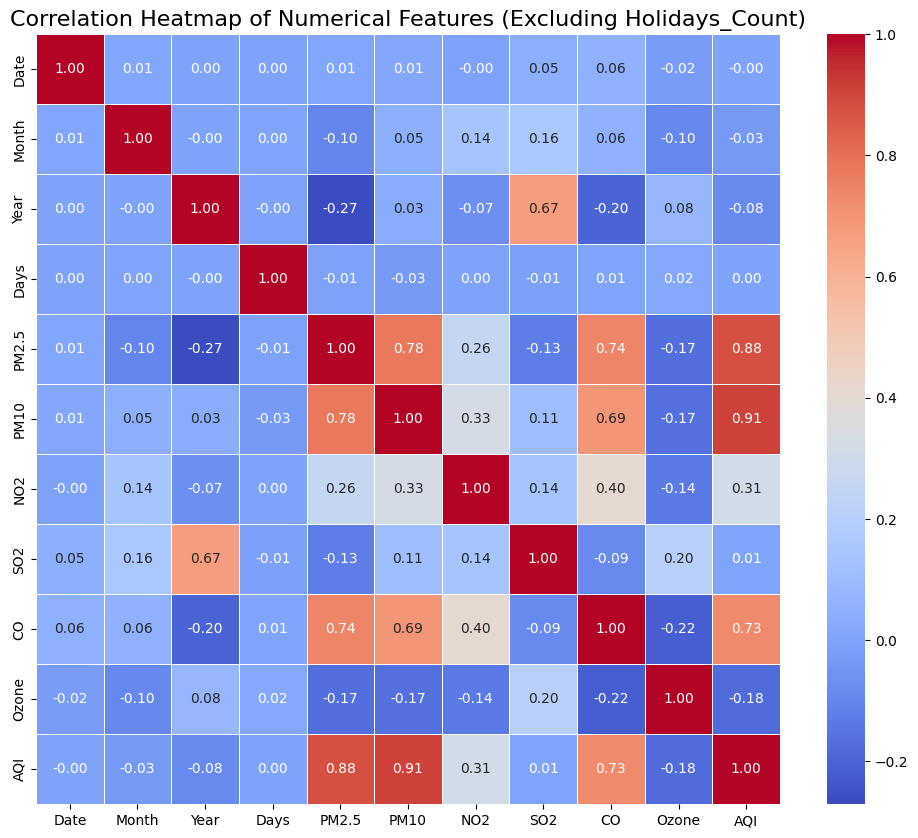

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- Data loading and preprocessing to define 'df' ---
# Ensure 'final_dataset.csv' is uploaded to your Colab environment.
df = pd.read_csv("final_dataset.csv")

# Missing Value Handling
df.fillna(df.mean(numeric_only=True), inplace=True)

# Outlier Treatment (IQR)
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower,
                       np.where(df[col] > upper, upper, df[col]))
# --- End of data loading and preprocessing ---

# 1. Calculate the correlation matrix for numerical features
# Select only numerical columns for correlation calculation
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Drop 'Holidays_Count' column as requested
if 'Holidays_Count' in numeric_df.columns:
    numeric_df = numeric_df.drop(columns=['Holidays_Count'])

correlation_matrix = numeric_df.corr()

# 2. Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix,
            annot=True, # Show correlation values on the heatmap
            cmap='coolwarm', # Use a diverging colormap
            fmt=".2f", # Format annotation values to two decimal places
            linewidths=.5 # Add lines between cells
           )

# 3. Add a title to the heatmap
plt.title('Correlation Heatmap of Numerical Features (Excluding Holidays_Count)', fontsize=16)

# 4. Display the plot
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Access regression metrics from the artifacts generated by the pipeline
# The 'artifacts' variable is available from the execution of cell 'wUbDdJOCe3D8'
regression_results = artifacts['results']

models_names = list(regression_results.keys())
r2_scores = [regression_results[name]['R2'] for name in models_names]
mae_scores = [regression_results[name]['MAE'] for name in models_names]
rmse_scores = [regression_results[name]['RMSE'] for name in models_names]

x = np.arange(len(models_names))  # the label locations
width = 0.25  # the width of the bars for each metric

fig, ax = plt.subplots(figsize=(15, 7))

# Plot R2 scores
rects1 = ax.bar(x - width, r2_scores, width, label='R2 Score', color='skyblue')
# Plot MAE scores
rects2 = ax.bar(x, mae_scores, width, label='MAE', color='lightcoral')
# Plot RMSE scores
rects3 = ax.bar(x + width, rmse_scores, width, label='RMSE', color='lightgreen')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_title('Model Performance: R2, MAE, and RMSE Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models_names, rotation=45, ha='right')
# Adjust y-limit as these are regression metrics
# R2 is typically 0-1, MAE/RMSE can be larger depending on the scale of AQI
ax.set_ylim(min(0, min(mae_scores + rmse_scores) - 10), max(1.0, max(mae_scores + rmse_scores) + 10)) # Dynamically adjust y-lim
ax.legend()

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

NameError: name 'artifacts' is not defined

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Access regression metrics from the artifacts generated by the pipeline
# The 'artifacts' variable is available from the execution of cell 'wUbDdJOCe3D8'
regression_results = artifacts['results']

models_names = list(regression_results.keys())
r2_scores = [regression_results[name]['R2'] for name in models_names]
mae_scores = [regression_results[name]['MAE'] for name in models_names]
rmse_scores = [regression_results[name]['RMSE'] for name in models_names]

x = np.arange(len(models_names))  # the label locations
width = 0.25  # the width of the bars for each metric

fig, ax = plt.subplots(figsize=(15, 7))

# Plot R2 scores
rects1 = ax.bar(x - width, r2_scores, width, label='R2 Score', color='skyblue')
# Plot MAE scores
rects2 = ax.bar(x, mae_scores, width, label='MAE', color='lightcoral')
# Plot RMSE scores
rects3 = ax.bar(x + width, rmse_scores, width, label='RMSE', color='lightgreen')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_title('Model Performance: R2, MAE, and RMSE Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models_names, rotation=45, ha='right')
# Adjust y-limit as these are regression metrics
# R2 is typically 0-1, MAE/RMSE can be larger depending on the scale of AQI
ax.set_ylim(min(0, min(mae_scores + rmse_scores) - 10), max(1.0, max(mae_scores + rmse_scores) + 10)) # Dynamically adjust y-lim
ax.legend()

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

In [ ]:
#!/usr/bin/env python3
"""
AQI prediction pipeline for Delhi dataset.

Place your CSV at: /mnt/data/final_dataset.csv
Run: python3 aqi_pipeline.py
"""

import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ---------------------------
# Configuration
# ---------------------------
DATA_PATH = "/final_dataset.csv"
RANDOM_STATE = 42
TEST_SIZE = 0.2
RF_N_ESTIMATORS = 200
OUTPUT_DIR = "/mnt/data/aqi_outputs"   # change as needed

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------------------------
# Utility functions
# ---------------------------
def load_data(path):
    df = pd.read_csv(path)
    return df

def impute_missing(df):
    # mean imputation for numeric columns only (works with pandas versions that require numeric_only)
    numeric_cols = df.select_dtypes(include=["number"]).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
    # for any remaining non-numeric NA (if any), drop or fill - here we drop rows with any remaining NA
    df = df.dropna().reset_index(drop=True)
    return df

def cap_outliers_iqr(df):
    numeric_cols = df.select_dtypes(include=["number"]).columns
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        # cap values instead of dropping
        df[col] = np.where(df[col] < lower, lower, np.where(df[col] > upper, upper, df[col]))
    return df

def prepare_features(df, target_col="AQI", drop_cols=None):
    if drop_cols is None:
        drop_cols = []
    X = df.drop(columns=[target_col] + drop_cols)
    y = df[target_col].copy()
    return X, y

def scale_features(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return scaler, X_train_scaled, X_test_scaled

def evaluate_model(model, X_test, y_test):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    # avoid using the "squared" kwarg to keep compatibility across sklearn versions
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return {"R2": r2, "MAE": mae, "RMSE": rmse}, preds

# ---------------------------
# Main pipeline
# ---------------------------
def main():
    # 1. Load
    print("Loading data from:", DATA_PATH)
    df = load_data(DATA_PATH)
    print("Original shape:", df.shape)
    print("Columns:", list(df.columns))
    print("-" * 60)

    # 2. Impute missing values
    df_clean = impute_missing(df.copy())
    print("After imputation shape:", df_clean.shape)

    # 3. Outlier capping (IQR)
    df_clean = cap_outliers_iqr(df_clean)
    print("After outlier capping shape:", df_clean.shape)

    # 4. Prepare X, y
    # If you want to drop Date/Month/Year replace drop_cols accordingly; here we keep all numeric columns
    X, y = prepare_features(df_clean, target_col="AQI")
    print("Feature shape (X):", X.shape)
    print("Target shape (y):", y.shape)
    print("-" * 60)

    # 5. Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f"Train shape: {X_train.shape}  Test shape: {X_test.shape}")
    print("-" * 60)

    # 6. Scaling
    scaler, X_train_scaled, X_test_scaled = scale_features(X_train, X_test)

    # 7. Train models
    models = {
        "Linear Regression": LinearRegression(),
        "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
        "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=RF_N_ESTIMATORS),
    }

    results = {}
    preds_store = {}

    for name, model in models.items():
        print(f"Training {name} ...")
        model.fit(X_train_scaled, y_train)
        metrics, preds = evaluate_model(model, X_test_scaled, y_test)
        results[name] = metrics
        preds_store[name] = preds
        print(f" -> {name} metrics: R2={metrics['R2']:.4f}, MAE={metrics['MAE']:.4f}, RMSE={metrics['RMSE']:.4f}")

    print("\nSummary of results:")
    for name, m in results.items():
        print(f"{name:20s} | R2: {m['R2']:.4f} | MAE: {m['MAE']:.4f} | RMSE: {m['RMSE']:.4f}")

    # 8. Select best model (by R2)
    best_model_name = max(results.items(), key=lambda x: x[1]["R2"])[0]
    best_model = models[best_model_name]
    best_preds = preds_store[best_model_name]
    print("-" * 60)
    print("Best model:", best_model_name)

    # 9. Plot Actual vs Predicted for best model
    plt.figure(figsize=(8,6))
    plt.scatter(y_test, best_preds, marker='x')
    plt.xlabel("Actual AQI")
    plt.ylabel("Predicted AQI")
    plt.title(f"Actual vs Predicted AQI ({best_model_name})")
    plt.grid(True)
    plt.tight_layout()
    plot_path1 = os.path.join(OUTPUT_DIR, f"actual_vs_pred_{best_model_name.replace(' ','_')}.png")
    plt.savefig(plot_path1, dpi=150)
    print("Saved plot:", plot_path1)
    plt.close()

    # 10. Feature importance (if RF)
    if hasattr(best_model, "feature_importances_"):
        importances = best_model.feature_importances_
        features = list(X.columns)
        # sort for nicer plotting
        sorted_idx = np.argsort(importances)
        sorted_features = [features[i] for i in sorted_idx]
        sorted_importances = importances[sorted_idx]

        plt.figure(figsize=(8,6))
        plt.barh(sorted_features, sorted_importances)
        plt.xlabel("Importance")
        plt.title(f"Feature Importance ({best_model_name})")
        plt.tight_layout()
        plot_path2 = os.path.join(OUTPUT_DIR, f"feature_importance_{best_model_name.replace(' ','_')}.png")
        plt.savefig(plot_path2, dpi=150)
        print("Saved plot:", plot_path2)
        plt.close()
    else:
        print("Best model has no feature_importances_ attribute (skipping importance plot).")

    # 11. Save best model and scaler
    model_path = os.path.join(OUTPUT_DIR, f"{best_model_name.replace(' ','_')}_model.pkl")
    scaler_path = os.path.join(OUTPUT_DIR, "scaler.pkl")
    joblib.dump(best_model, model_path)
    joblib.dump(scaler, scaler_path)
    print("Saved model to:", model_path)
    print("Saved scaler to:", scaler_path)

    # 12. Save evaluation table
    df_results = pd.DataFrame(results).T
    df_results.to_csv(os.path.join(OUTPUT_DIR, "model_results.csv"))
    print("Saved model results CSV.")

    return {
        "original_shape": df.shape,
        "after_preprocessing_shape": df_clean.shape,
        "X_train_shape": X_train.shape,
        "X_test_shape": X_test.shape,
        "results": results,
        "best_model_name": best_model_name,
        "outputs_dir": OUTPUT_DIR
    }


if __name__ == "__main__":
    artifacts = main()

Loading data from: final_dataset.csv


FileNotFoundError: [Errno 2] No such file or directory: 'final_dataset.csv'

In [ ]:
#!/usr/bin/env python3
"""
AQI prediction pipeline for Delhi dataset.

Place your CSV at: /mnt/data/final_dataset.csv
Run: python3 aqi_pipeline.py
"""

import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ---------------------------
# Configuration
# ---------------------------
DATA_PATH = "/final_dataset.csv"
RANDOM_STATE = 42
TEST_SIZE = 0.2
RF_N_ESTIMATORS = 200
OUTPUT_DIR = "/mnt/data/aqi_outputs"   # change as needed

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------------------------
# Utility functions
# ---------------------------
def load_data(path):
    df = pd.read_csv(path)
    return df

def impute_missing(df):
    # mean imputation for numeric columns only (works with pandas versions that require numeric_only)
    numeric_cols = df.select_dtypes(include=["number"]).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
    # for any remaining non-numeric NA (if any), drop or fill - here we drop rows with any remaining NA
    df = df.dropna().reset_index(drop=True)
    return df

def cap_outliers_iqr(df):
    numeric_cols = df.select_dtypes(include=["number"]).columns
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        # cap values instead of dropping
        df[col] = np.where(df[col] < lower, lower, np.where(df[col] > upper, upper, df[col]))
    return df

def prepare_features(df, target_col="AQI", drop_cols=None):
    if drop_cols is None:
        drop_cols = []
    X = df.drop(columns=[target_col] + drop_cols)
    y = df[target_col].copy()
    return X, y

def scale_features(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return scaler, X_train_scaled, X_test_scaled

def evaluate_model(model, X_test, y_test):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    # avoid using the "squared" kwarg to keep compatibility across sklearn versions
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return {"R2": r2, "MAE": mae, "RMSE": rmse}, preds

# ---------------------------
# Main pipeline
# ---------------------------
def main():
    # 1. Load
    print("Loading data from:", DATA_PATH)
    df = load_data(DATA_PATH)
    print("Original shape:", df.shape)
    print("Columns:", list(df.columns))
    print("-" * 60)

    # 2. Impute missing values
    df_clean = impute_missing(df.copy())
    print("After imputation shape:", df_clean.shape)

    # 3. Outlier capping (IQR)
    df_clean = cap_outliers_iqr(df_clean)
    print("After outlier capping shape:", df_clean.shape)

    # 4. Prepare X, y
    # If you want to drop Date/Month/Year replace drop_cols accordingly; here we keep all numeric columns
    X, y = prepare_features(df_clean, target_col="AQI")
    print("Feature shape (X):", X.shape)
    print("Target shape (y):", y.shape)
    print("-" * 60)

    # 5. Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f"Train shape: {X_train.shape}  Test shape: {X_test.shape}")
    print("-" * 60)

    # 6. Scaling
    scaler, X_train_scaled, X_test_scaled = scale_features(X_train, X_test)

    # 7. Train models
    models = {
        "Linear Regression": LinearRegression(),
        "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
        "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=RF_N_ESTIMATORS),
    }

    results = {}
    preds_store = {}

    for name, model in models.items():
        print(f"Training {name} ...")
        model.fit(X_train_scaled, y_train)
        metrics, preds = evaluate_model(model, X_test_scaled, y_test)
        results[name] = metrics
        preds_store[name] = preds
        print(f" -> {name} metrics: R2={metrics['R2']:.4f}, MAE={metrics['MAE']:.4f}, RMSE={metrics['RMSE']:.4f}")

    print("\nSummary of results:")
    for name, m in results.items():
        print(f"{name:20s} | R2: {m['R2']:.4f} | MAE: {m['MAE']:.4f} | RMSE: {m['RMSE']:.4f}")

    # 8. Select best model (by R2)
    best_model_name = max(results.items(), key=lambda x: x[1]["R2"])[0]
    best_model = models[best_model_name]
    best_preds = preds_store[best_model_name]
    print("-" * 60)
    print("Best model:", best_model_name)

    # 9. Plot Actual vs Predicted for best model
    plt.figure(figsize=(8,6))
    plt.scatter(y_test, best_preds, marker='x')
    plt.xlabel("Actual AQI")
    plt.ylabel("Predicted AQI")
    plt.title(f"Actual vs Predicted AQI ({best_model_name})")
    plt.grid(True)
    plt.tight_layout()
    plot_path1 = os.path.join(OUTPUT_DIR, f"actual_vs_pred_{best_model_name.replace(' ','_')}.png")
    plt.savefig(plot_path1, dpi=150)
    print("Saved plot:", plot_path1)
    plt.close()

    # 10. Feature importance (if RF)
    if hasattr(best_model, "feature_importances_"):
        importances = best_model.feature_importances_
        features = list(X.columns)
        # sort for nicer plotting
        sorted_idx = np.argsort(importances)
        sorted_features = [features[i] for i in sorted_idx]
        sorted_importances = importances[sorted_idx]

        plt.figure(figsize=(8,6))
        plt.barh(sorted_features, sorted_importances)
        plt.xlabel("Importance")
        plt.title(f"Feature Importance ({best_model_name})")
        plt.tight_layout()
        plot_path2 = os.path.join(OUTPUT_DIR, f"feature_importance_{best_model_name.replace(' ','_')}.png")
        plt.savefig(plot_path2, dpi=150)
        print("Saved plot:", plot_path2)
        plt.close()
    else:
        print("Best model has no feature_importances_ attribute (skipping importance plot).")

    # 11. Save best model and scaler
    model_path = os.path.join(OUTPUT_DIR, f"{best_model_name.replace(' ','_')}_model.pkl")
    scaler_path = os.path.join(OUTPUT_DIR, "scaler.pkl")
    joblib.dump(best_model, model_path)
    joblib.dump(scaler, scaler_path)
    print("Saved model to:", model_path)
    print("Saved scaler to:", scaler_path)

    # 12. Save evaluation table
    df_results = pd.DataFrame(results).T
    df_results.to_csv(os.path.join(OUTPUT_DIR, "model_results.csv"))
    print("Saved model results CSV.")

    return {
        "original_shape": df.shape,
        "after_preprocessing_shape": df_clean.shape,
        "X_train_shape": X_train.shape,
        "X_test_shape": X_test.shape,
        "results": results,
        "best_model_name": best_model_name,
        "outputs_dir": OUTPUT_DIR
    }


if __name__ == "__main__":
    artifacts = main()

Loading data from: /final_dataset.csv
Original shape: (1461, 12)
Columns: ['Date', 'Month', 'Year', 'Holidays_Count', 'Days', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'AQI']
------------------------------------------------------------
After imputation shape: (1461, 12)
After outlier capping shape: (1461, 12)
Feature shape (X): (1461, 11)
Target shape (y): (1461,)
------------------------------------------------------------
Train shape: (1168, 11)  Test shape: (293, 11)
------------------------------------------------------------
Training Linear Regression ...
 -> Linear Regression metrics: R2=0.9149, MAE=22.8203, RMSE=33.2349
Training Decision Tree ...
 -> Decision Tree metrics: R2=0.8535, MAE=28.6621, RMSE=43.6017
Training Random Forest ...
 -> Random Forest metrics: R2=0.9335, MAE=19.0860, RMSE=29.3727

Summary of results:
Linear Regression    | R2: 0.9149 | MAE: 22.8203 | RMSE: 33.2349
Decision Tree        | R2: 0.8535 | MAE: 28.6621 | RMSE: 43.6017
Random Forest        | R2: 0

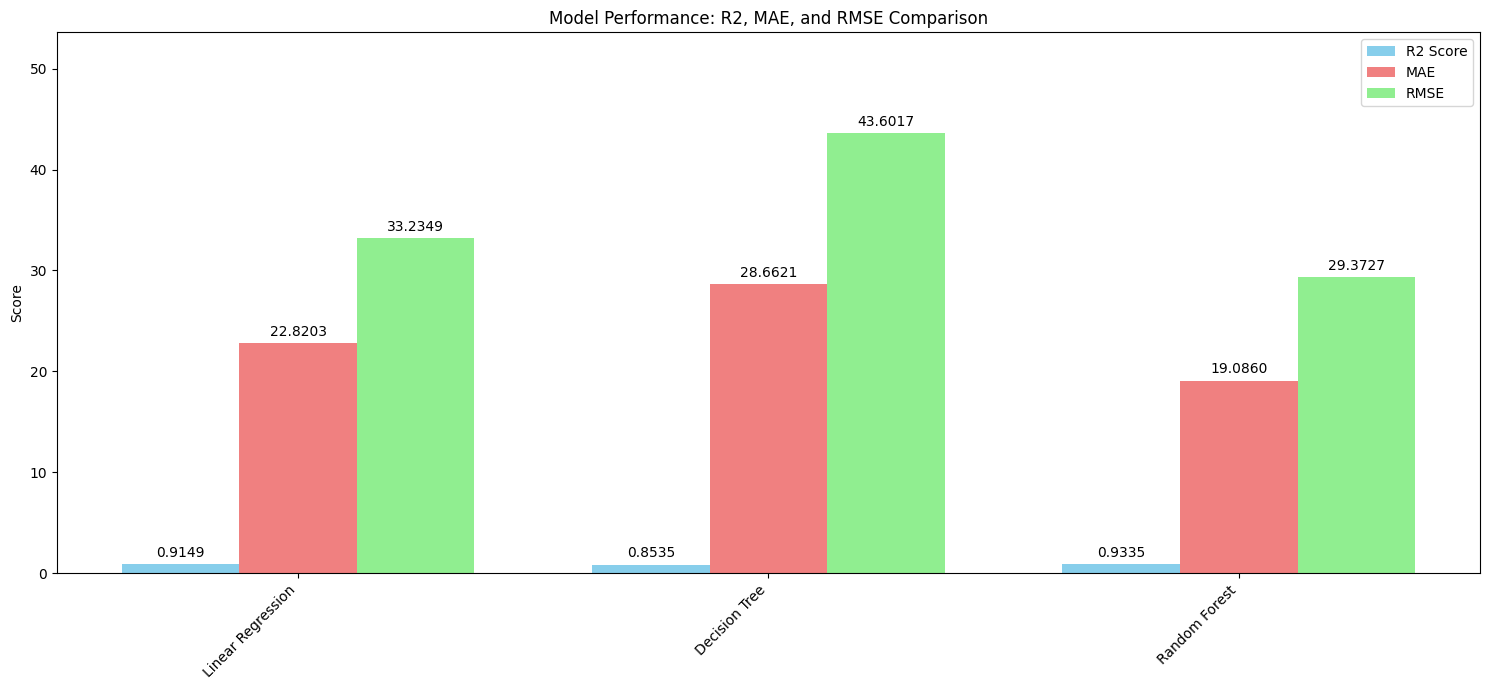

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Access regression metrics from the artifacts generated by the pipeline
# The 'artifacts' variable is available from the execution of cell 'wUbDdJOCe3D8'
regression_results = artifacts['results']

models_names = list(regression_results.keys())
r2_scores = [regression_results[name]['R2'] for name in models_names]
mae_scores = [regression_results[name]['MAE'] for name in models_names]
rmse_scores = [regression_results[name]['RMSE'] for name in models_names]

x = np.arange(len(models_names))  # the label locations
width = 0.25  # the width of the bars for each metric

fig, ax = plt.subplots(figsize=(15, 7))

# Plot R2 scores
rects1 = ax.bar(x - width, r2_scores, width, label='R2 Score', color='skyblue')
# Plot MAE scores
rects2 = ax.bar(x, mae_scores, width, label='MAE', color='lightcoral')
# Plot RMSE scores
rects3 = ax.bar(x + width, rmse_scores, width, label='RMSE', color='lightgreen')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_title('Model Performance: R2, MAE, and RMSE Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models_names, rotation=45, ha='right')
# Adjust y-limit as these are regression metrics
# R2 is typically 0-1, MAE/RMSE can be larger depending on the scale of AQI
ax.set_ylim(min(0, min(mae_scores + rmse_scores) - 10), max(1.0, max(mae_scores + rmse_scores) + 10)) # Dynamically adjust y-lim
ax.legend()

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

In [ ]:
import os

file_path = '/final_dataset.csv'
if os.path.exists(file_path):
    print(f"The file '{file_path}' exists.")
else:
    print(f"The file '{file_path}' does NOT exist. Please ensure it's uploaded to the root of your Colab environment.")

The file '/final_dataset.csv' exists.
